In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.optimize import minimize
from astropy.timeseries import LombScargle
from scipy import stats
from george import kernels
import george
from astropy.io import fits
from functions import *
from glob import glob
from gp_model_params import info
from tqdm import tqdm
import pickle as pkl
from pathlib import Path

/Users/somayeh/opt/anaconda3/envs/pyt313/lib/python3.13/site-packages/george/metrics.py:103: RuntimeWarning: divide by zero encountered in log
  parameters.append(np.log(metric))


In [12]:
# Here we read Roman cadences for the Galactic Bulge
Roman_sampling_short = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2 = np.load('lc_example/roman_times_longcadence2.npy')

Roman_sampling_short_min = min(Roman_sampling_short)
Roman_sampling_short = Roman_sampling_short - Roman_sampling_short_min
Roman_sampling_long_min = min(Roman_sampling_long)
Roman_sampling_long = Roman_sampling_long - Roman_sampling_long_min
# Roman_sampling_long2_min = min(Roman_sampling_long2)
Roman_sampling_long2 = Roman_sampling_long2 - Roman_sampling_short_min
Roman_max_short_time = max(Roman_sampling_short)

smallest_max_t = max(max(Roman_sampling_short), 
					 max(Roman_sampling_long),
					 max(Roman_sampling_long2))

t_base = Roman_sampling_short
t_base_long = Roman_sampling_long
t_base_long2 = Roman_sampling_long2
t_regular = np.linspace(0, max(Roman_sampling_short), 750000)

In [49]:
# Define home directory
home = str(Path.home())
output_plot = 'output/plots/DN/'

In [4]:
tp = 'DN'
direc = home+'/Research_data/Bulge_Variables/%s/'%tp
output_file = 'output/'

In [5]:
if not tp == 'DN':
    period = float(list_periods[list_periods[:, 0] == ID][0][1])
else:
    period = np.nan

In [6]:
with open(output_file + 'DN_peaks_bank.pkl', 'rb') as file:
	peaks_bank = pkl.load(file)

Reading light curve OGLE-BLG-DN-0001...


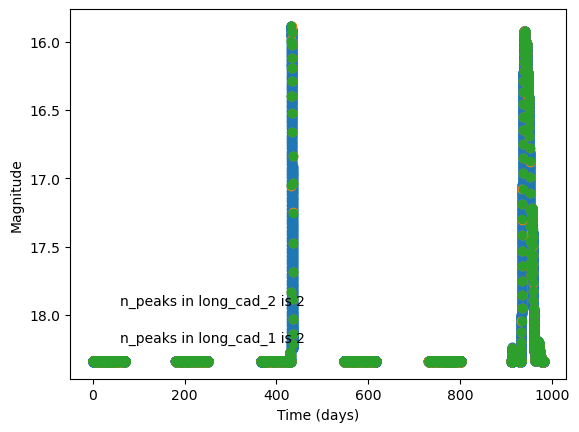

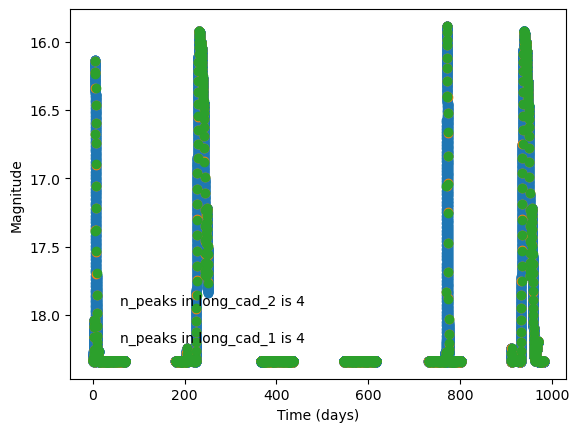

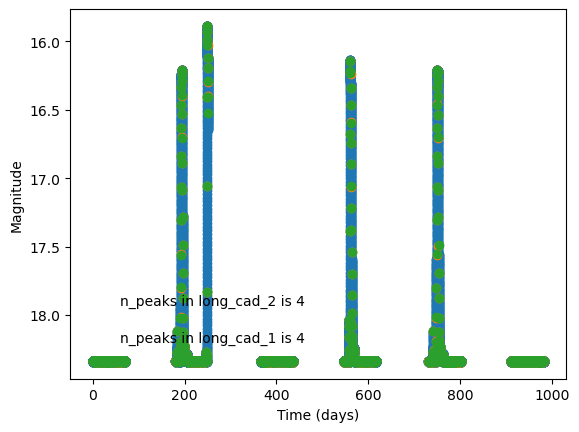

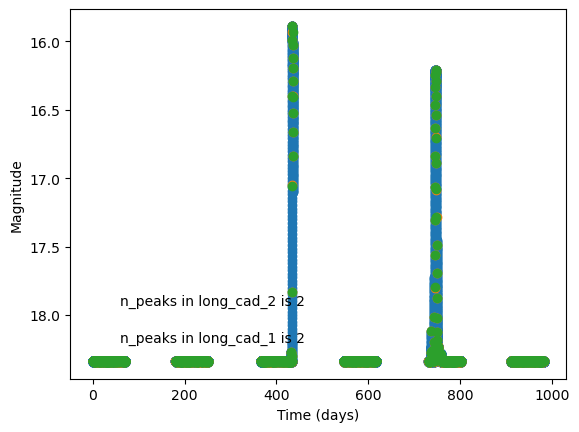

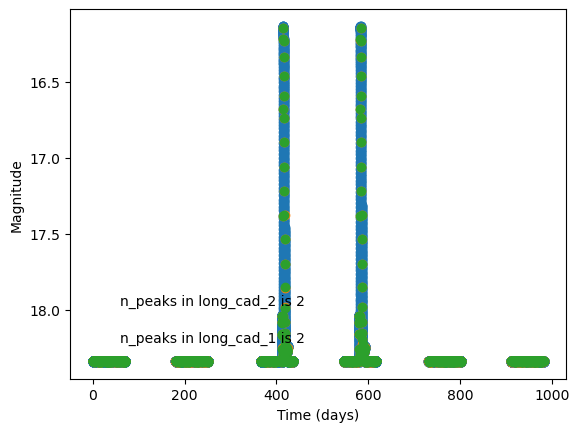

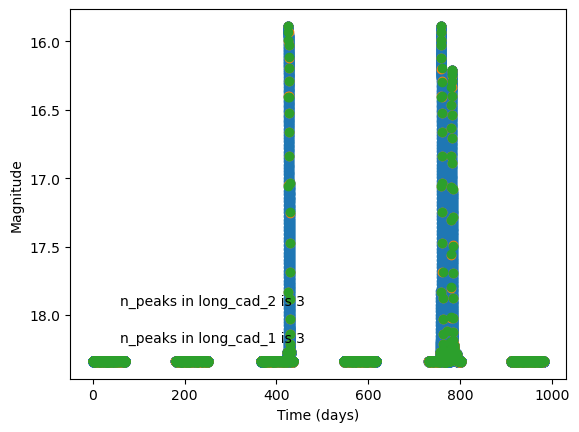

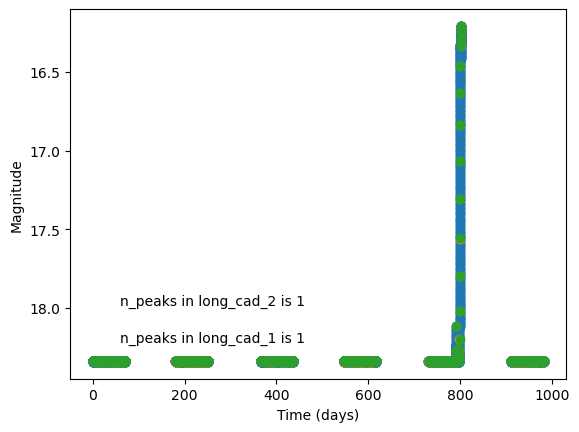

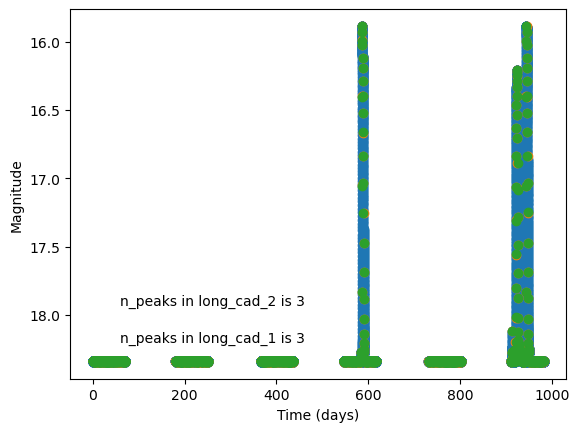

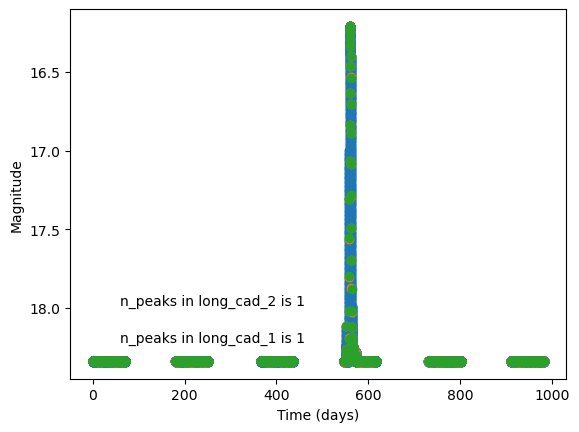

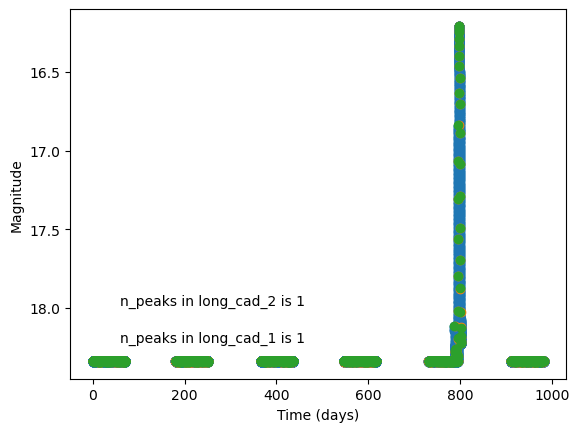

In [238]:
n_sim_lc_per_obs_lc = 10
max_n_peaks = 6
all_lc = {}
counter = 0
batch_size = 100

for key in list(peaks_bank.keys())[:1]:

    print('Reading light curve %s...'%key)
    band = 'I'
    path = direc + '%s_multiband_lc.fits'%(str(key))
    # Read the light curve data
    period, df_ = read_fits(path, period=period, tp=tp)
    try:
        df = df_[df_.band == band]
        # print(df_.groupby('band').size())
    except AttributeError:
        print('Error: %s band does not exist. Skipping...' % band)
    
    all_peaks = peaks_bank[key]
    n_all_peaks = len(all_peaks)
    if n_all_peaks == 0:
        print('%s has no peaks.'%str(key))
        continue

    # n_peaks is a list of numbers for number of peaks for each final simulated light curve
    if n_all_peaks >= 6:
        n_peaks = np.random.choice(np.linspace(1, max_n_peaks, max_n_peaks, dtype=int), size=10)
    else:
        n_peaks = np.random.choice(np.linspace(1, n_all_peaks, n_all_peaks, dtype=int), size=10)
    

    noise_amp = 0.001
    baseline_mag = np.median(df_.m)
    y_base = np.ones_like(t_base) * baseline_mag + np.random.normal(0, noise_amp, size=len(t_base))
    y_base_long = np.ones_like(t_base_long) * baseline_mag + np.random.normal(0, noise_amp, size=len(t_base_long))
    y_base_long2 = np.ones_like(t_base_long2) * baseline_mag + np.random.normal(0, noise_amp, size=len(t_base_long2))
    y_base_regular = np.ones_like(t_regular) * baseline_mag + np.random.normal(0, noise_amp, size=len(t_regular))
    
    y_sim = y_base.copy()
    y_sim_long = y_base_long.copy()
    y_sim_long2 = y_base_long2.copy()
    y_sim_regular = y_base_regular.copy()

    for i in range(n_sim_lc_per_obs_lc):

        ID = str(key)+'_ind'+str(i)+'_'+str(n_peaks[i])
        all_lc[ID] = {}

        # rand_peak_times = np.random.choice(t_base, size=n_peaks[i])
        min_gap = 10
        rand_peak_times = []
        available_mask = np.ones(len(t_base), dtype=bool)
        
        for _ in range(n_peaks[i]):
            available_indices = np.where(available_mask)[0]
            chosen_idx = np.random.choice(available_indices)
            chosen_time = t_base[chosen_idx]
            rand_peak_times.append(chosen_time)
            
            # Exclude times within `min_gap` of the chosen peak
            available_mask &= np.abs(t_base - chosen_time) > min_gap
        
        rand_peak_times = np.array(rand_peak_times)

        y_sim = y_base.copy()
        y_sim_long = y_base_long.copy()
        y_sim_long2 = y_base_long2.copy()
        y_sim_regular = y_base_regular.copy()

        peak_ind = np.random.choice(np.linspace(0, n_all_peaks-1, n_all_peaks, dtype=int), size=n_peaks[i])
        counter1 = 0
        counter2 = 0
        for j in range(n_peaks[i]):

            peak_dict = all_peaks[peak_ind[j]]
            gp = peak_dict["gp"]
            xfit = peak_dict["xfit"]
            x = peak_dict["x"]
            t_of_max_flux = peak_dict["x"][np.argmin(peak_dict["yfit"])]
            dt_left = t_of_max_flux - x.min()
            dt_right = x.max() - t_of_max_flux   
            interp_y1 = interp1d(peak_dict["x_new"], peak_dict["y_new"], kind='linear', bounds_error=False, fill_value=np.nan)
            
            t0 = rand_peak_times[j]
            mask = (t_base > t0 - dt_left) & (t_base < t0 + dt_right)
            mask_regular = (t_regular > t0 - dt_left) & (t_regular < t0 + dt_right)
            
            
            
            if np.sum(mask)!=0:
                t_local = t_base[mask] - t_base[mask].min() + dt_left
                peak_mag = interp_y1(t_local-t_local.min())
                y_sim[mask] += peak_mag-max(peak_mag)
            
            if np.sum(mask_regular) != 0:
                t_local_regular = t_regular[mask_regular] - t_regular[mask_regular].min() + dt_left
            
                peak_mag_regular = interp_y1(t_local_regular-t_local_regular.min())
                y_sim_regular[mask_regular] += peak_mag_regular-max(peak_mag_regular)
            
            mask_long = (t_base_long > t0 - dt_left) & (t_base_long < t0 + dt_right)
            if np.sum(mask_long)!=0:
                counter1 += 1
                t_local_long = t_base_long[mask_long] - t_base_long[mask_long].min() + dt_left
                peak_mag_long = interp_y1(t_local_long-t_local_long.min())
                y_sim_long[mask_long] += peak_mag_long-max(peak_mag_long)
        
            mask_long2 = (t_base_long2 > t0 - dt_left) & (t_base_long2 < t0 + dt_right)
            if np.sum(mask_long2)!=0:
                counter2 += 1
                t_local_long2 = t_base_long2[mask_long2] - t_base_long2[mask_long2].min() + dt_left
                peak_mag_long2 = interp_y1(t_local_long2 - t_local_long2.min())
                y_sim_long2[mask_long2] += peak_mag_long2-max(peak_mag_long2)
        
        plt.figure()
        plt.scatter(t_base, y_sim)
        plt.scatter(t_base_long, y_sim_long)
        plt.scatter(t_base_long2, y_sim_long2)
        # plt.scatter(t_regular, y_sim_regular)
        plt.gca().invert_yaxis()
        if counter1>0:
            plt.text(0.1, 0.1, 'n_peaks in long_cad_1 is %i'%counter1, transform=plt.gca().transAxes)
        if counter2>0:
            plt.text(0.1, 0.2, 'n_peaks in long_cad_2 is %i'%counter2, transform=plt.gca().transAxes)
        plt.xlabel('Time (days)')
        plt.ylabel('Magnitude')
        # plt.xlim(700, 800)
        plt.savefig(output_plot + ID +'.png')


        all_lc[ID]['%s_band_t_base_Roman_short'%band] = t_base
        all_lc[ID]['%s_band_t_base_Roman_long'%band] = t_base_long
        all_lc[ID]['%s_band_t_base_Roman_long2'%band] = t_base_long2
        all_lc[ID]['%s_band_Roman_m_official_sampling_short'%band] = y_sim
        all_lc[ID]['%s_band_Roman_m_official_sampling_long'%band] = y_sim_long
        all_lc[ID]['%s_band_Roman_m_official_sampling_long2'%band] = y_sim_long2
        all_lc[ID]['%s_band_Roman_m_regular_sampling'%band] = y_sim_regular
        all_lc[ID]['%s_band_Roman_time_regular_sampling'%band] = t_regular
        counter += 1

        if (counter/batch_size)%1==0:
        
            batch_number = int(counter/batch_size)
            pkl.dump(all_lc,
                     open(output_file+'DN_Roman_lc_batch_%i_out_of_%i_lcs_includes_regular.pkl'%(batch_number, num_lc),
                     'wb'))
            all_lc = {}
	

    

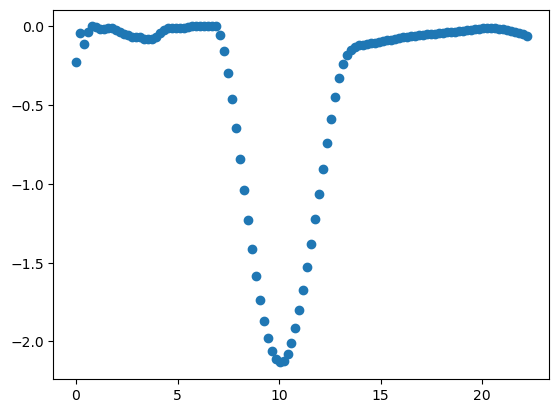

In [239]:
i = 2
plt.scatter(all_peaks[i]["x_new"], all_peaks[i]["y_new"])

In [215]:
i = -1
interp_y1 = interp1d(peak_dict["x_new"], peak_dict["y_new"],  bounds_error=False, fill_value=np.nan)

In [234]:
t_test = t_local-t_local.min()
F = interp_y1(t_test)*-1
t_max = t_test[np.argmax(F)]

baseline_mask = F < np.median(F)
baseline = np.median(F[baseline_mask])
sigma_noise = np.std(F[baseline_mask])
threshold = baseline + 3 * sigma_noise

left_idx  = next(i for i in range(len(t_test))          if F[i] > threshold)
right_idx = next(i for i in range(len(t_test)-1, 0, -1) if F[i] > threshold)

y_sim_test = np.ones_like(F) * baseline #F.copy()
mask = ( t_test< t_test[right_idx]) &\
        ( t_test> t_test[left_idx])

y_sim_test[mask] = F[mask]#np.ones_like(y_sim_test[mask]) * baseline #+ np.random.normal(0, 0.001, size=len(y_sim[mask]))

y_sim_test = y_sim_test - np.median(y_sim_test)

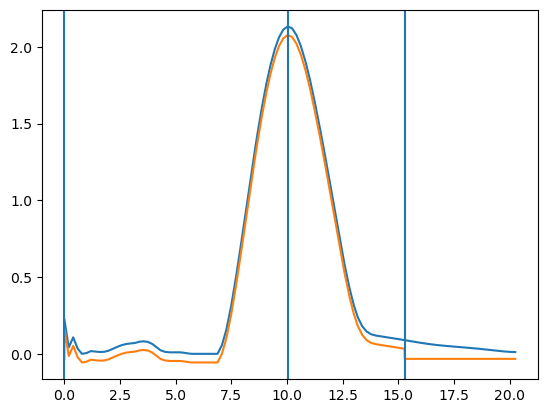

In [235]:
plt.plot(t_test, F)
plt.plot(t_test, y_sim_test)
plt.axvline(t_max)
plt.axvline(t_test[left_idx])
plt.axvline(t_test[right_idx])

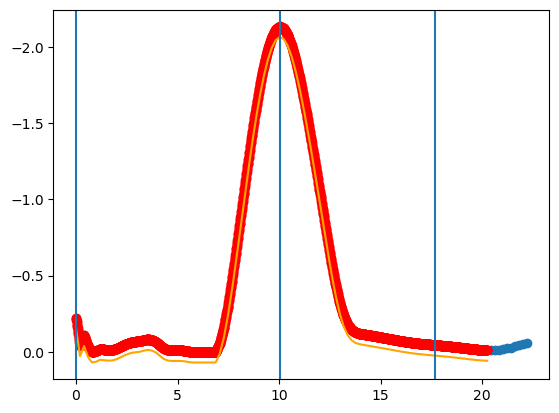

In [214]:


plt.scatter(peak_dict["x_new"], peak_dict["y_new"])
plt.scatter(t_local- t_local.min(), interp_y1(t_local- t_local.min()), color='r')
plt.plot(t_local-t_local.min(), -1*y_sim_test, color='orange')

# plt.plot(t_local, spl(t_local), color='g')
plt.axvline(t_max)
plt.axvline(t_local[left_idx]-t_local.min())
plt.axvline(t_local[right_idx]-t_local.min())
plt.gca().invert_yaxis()


In [180]:
t_local[t_local<t_max]

array([3.14554   , 3.15394278, 3.16234556, 3.17074833, 3.17915111,
       3.18755389, 3.19595667])

(180.0, 260.0)

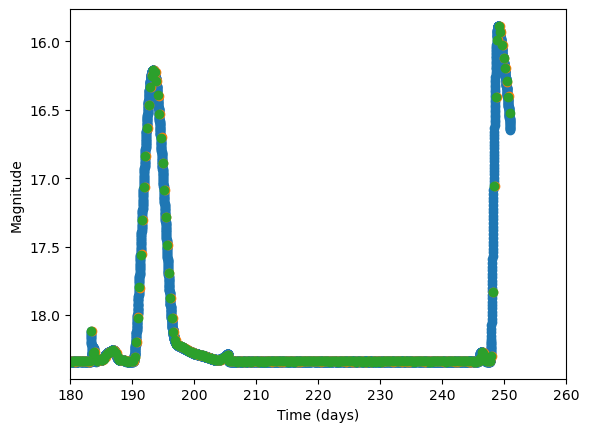

In [248]:
key = list(all_lc.keys())[2]
dict_ = all_lc[key]

plt.figure()
plt.scatter(dict_['I_band_t_base_Roman_short'], 
            dict_['I_band_Roman_m_official_sampling_short'])
plt.scatter(dict_['I_band_t_base_Roman_long'], 
            dict_['I_band_Roman_m_official_sampling_long'])
plt.scatter(dict_['I_band_t_base_Roman_long2'], 
            dict_['I_band_Roman_m_official_sampling_long2'])
# plt.scatter(dict_['I_band_Roman_time_regular_sampling'], 
#             dict_['I_band_Roman_m_regular_sampling'])
plt.gca().invert_yaxis()
# if counter1>0:
#     plt.text(0.1, 0.1, 'n_peaks in long_cad_1 is %i'%counter1, transform=plt.gca().transAxes)
# if counter2>0:
#     plt.text(0.1, 0.2, 'n_peaks in long_cad_2 is %i'%counter2, transform=plt.gca().transAxes)
plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xlim(180, 260)

In [98]:
t_local

array([ 5.15322   ,  5.16162278,  5.17002556, ..., 19.39592833,
       19.40433111, 19.41273389], shape=(1698,))

In [73]:
np.median(np.diff(peak_dict["x_new"]))

np.float64(0.17402256097894409)

In [74]:
np.median(np.diff(t_base))

np.float64(0.008402777835726738)

(950.0, 965.0)

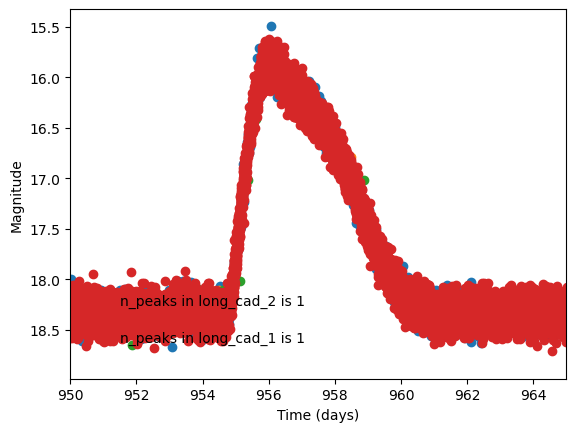

In [176]:
plt.figure()
plt.scatter(t_base, y_sim)
plt.scatter(t_base_long, y_sim_long)
plt.scatter(t_base_long2, y_sim_long2)
plt.scatter(t_regular, y_sim_regular)
plt.gca().invert_yaxis()
if counter1>0:
    plt.text(0.1, 0.1, 'n_peaks in long_cad_1 is %i'%counter1, transform=plt.gca().transAxes)
if counter2>0:
    plt.text(0.1, 0.2, 'n_peaks in long_cad_2 is %i'%counter2, transform=plt.gca().transAxes)
plt.xlabel('Time (days)')
plt.ylabel('Magnitude')
plt.xlim(950, 965)

array([0, 1, 2, 3])

In [42]:
n_all_peaks

4

In [28]:
np.random.choice(np.linspace(1, 6, 6, dtype=int), size=10)

array([6, 5, 6, 6, 1, 3, 4, 4, 3, 5])

dict_keys(['gp', 'xfit', 'yfit', 'x', 'y', 'x_new', 'y_new', 'interpol', 't_peak'])
dict_keys(['gp', 'xfit', 'yfit', 'x', 'y', 'x_new', 'y_new', 'interpol', 't_peak'])


(3900.0, 4100.0)

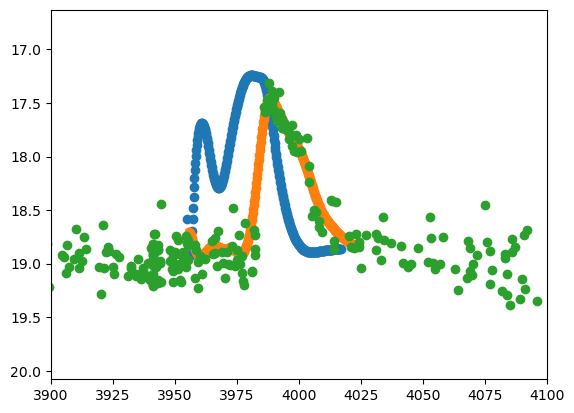

In [17]:
for peak in all_peaks:
    print(peak.keys())
    plt.scatter(peak['x_new']+3955, peak['y_new']+np.median(df_.m))
plt.scatter(df_.t, df_.m)
plt.gca().invert_yaxis()
plt.xlim(3900,4100)

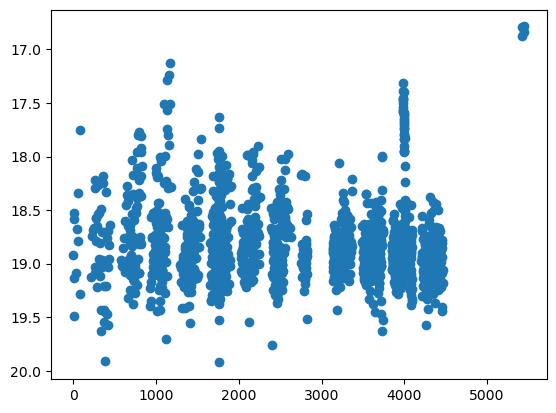

In [18]:
plt.scatter(df_.t, df_.m)
plt.gca().invert_yaxis()

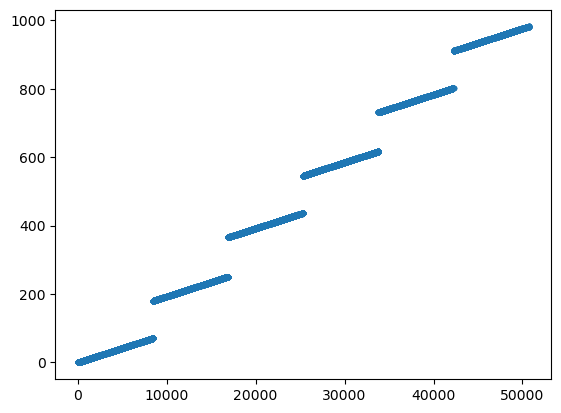

In [60]:
plt.plot(Roman_sampling_short, '.')